# M4.Ex2: Penguins Classification (PyCaret)

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M6/exercises/ex2_pycaret_classification.ipynb)

## Exercise

Your task is to follow the steps outlined here, and apply them on the **Palmer Penguins Dataset** below:

- [**🚀 Classification**](https://pycaret.gitbook.io/docs/get-started/quickstart#classification)
    - Setup
    - Compare Models
    - Analyze Model
    - Predictions
    - Save the model

## Palmer Penguins Dataset

The goal of palmer penguins is to provide a great dataset for data exploration & visualization, as an alternative to iris.

The data contains 344 penguins. There are 3 different species of penguins in this dataset, collected from 3 islands in the Palmer Archipelago, Antarctica.

- Features: `4` numerical, `2` categorical
- Target: `species` (Categorical / 3 classes)
- Size: `344` samples
- Source: [Palmer Penguins](https://allisonhorst.github.io/palmerpenguins/)

In [1]:
!pip install pycaret

In [2]:
import pandas as pd

### Load the data

In [3]:
import seaborn as sns

penguins = sns.load_dataset('penguins')
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


**Dataset Cleaning:**

The dataset had missing values, so I performed basic cleaning by removing any rows containing missing values and then reset the index.


In [4]:
penguins_clean = penguins.dropna(
    subset=['species', 'sex', 'island',
            'bill_length_mm', 'bill_depth_mm',
            'flipper_length_mm', 'body_mass_g']
).reset_index(drop=True)

## Experiments

1. **First experiment**:
    - X = Flipper Length (numerical) & Bill Length (numerical)
    - y = Species (categorical)
2. **Second experiment**:
    - X = Weights (numerical) & Species (categorical)
    - y = Sex (categroical)
3. **Third experiment**:
    - X = `island`, `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`
    - y = Sex and Species (multi-label classification)

## **Answers:**

# **EXPERIMENT 1:**

1. First experiment:

    * X = Flipper Length (numerical) & Bill Length (numerical)
    * y = Species (categorical)

### **Setup:**

In [5]:
from pycaret.classification import *

exp1 = setup(data=penguins_clean[['flipper_length_mm','bill_length_mm','species']], target='species',session_id=123)

,Description,Value
0,Session id,123
1,Target,species
2,Target type,Multiclass
3,Target mapping,"Adelie: 0, Chinstrap: 1, Gentoo: 2"
4,Original data shape,"(333, 3)"
5,Transformed data shape,"(333, 3)"
6,Transformed train set shape,"(233, 3)"
7,Transformed test set shape,"(100, 3)"
8,Numeric features,2
9,Preprocess,True


### **Compare Models:**

In [6]:
best1 = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.9784,0.9900,0.9784,0.9812,0.9783,0.9664,0.9678,0.1790
lr,Logistic Regression,0.9743,0.0000,0.9743,0.9771,0.9732,0.9594,0.9614,0.9440
dt,Decision Tree Classifier,0.9699,0.9777,0.9699,0.9738,0.9697,0.9531,0.9550,0.0280
gbc,Gradient Boosting Classifier,0.9699,0.0000,0.9699,0.9742,0.9700,0.9534,0.9553,0.3460
lightgbm,Light Gradient Boosting Machine,0.9699,0.9937,0.9699,0.9749,0.9701,0.9533,0.9555,0.1070
et,Extra Trees Classifier,0.9656,0.9901,0.9656,0.9685,0.9652,0.9462,0.9478,0.1730
qda,Quadratic Discriminant Analysis,0.9612,0.0000,0.9612,0.9626,0.9598,0.9388,0.9405,0.0250
lda,Linear Discriminant Analysis,0.9612,0.0000,0.9612,0.9649,0.9595,0.9387,0.9415,0.0410
xgboost,Extreme Gradient Boosting,0.9612,0.9962,0.9612,0.9656,0.9614,0.9395,0.9414,0.0600
knn,K Neighbors Classifier,0.9571,0.9814,0.9571,0.9609,0.9544,0.9319,0.9349,0.0420


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

In [7]:
best1

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='sqrt',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       monotonic_cst=None, n_estimators=100, n_jobs=-1,
                       oob_score=False, random_state=123, verbose=0,
                       warm_start=False)

### **Analyze Model:**

In [8]:
evaluate_model(best1)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

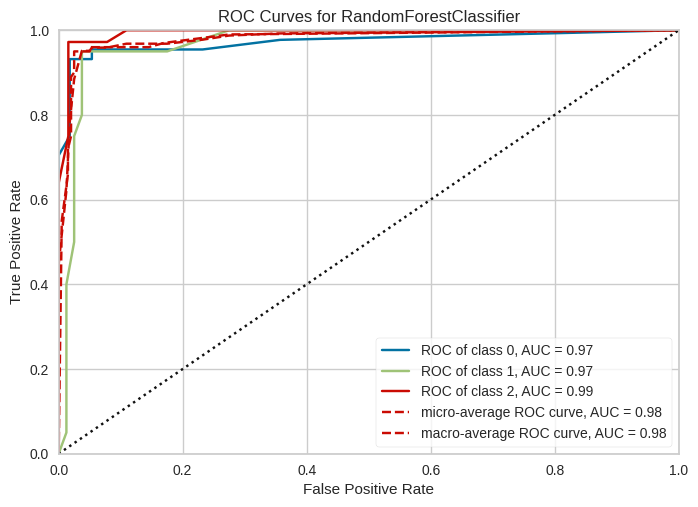

In [9]:
plot_model(best1, plot = 'auc')

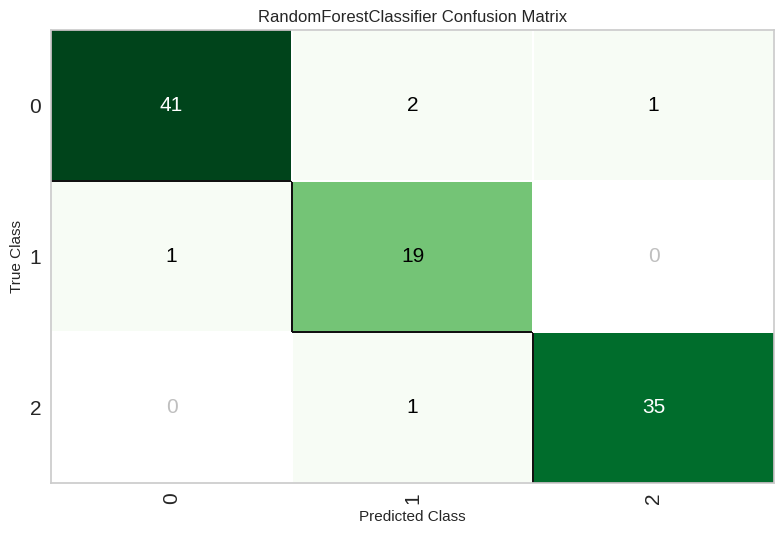

In [10]:
plot_model(best1, plot = 'confusion_matrix')

### **Predictions:**

In [11]:
predict_model(best1)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.9500,0.9794,0.9500,0.9523,0.9505,0.9221,0.9227


,flipper_length_mm,bill_length_mm,species,prediction_label,prediction_score
84,202.0,35.700001,Adelie,Adelie,0.94
109,196.0,42.700001,Adelie,Adelie,0.98
111,199.0,37.299999,Adelie,Adelie,1.00
143,193.0,37.799999,Adelie,Adelie,1.00
263,210.0,46.599998,Gentoo,Gentoo,1.00
...,...,...,...,...,...
159,201.0,52.000000,Chinstrap,Chinstrap,1.00
153,197.0,51.299999,Chinstrap,Chinstrap,0.99
140,190.0,39.200001,Adelie,Adelie,1.00
310,203.0,48.400002,Gentoo,Chinstrap,0.97


### **Save the model:**

In [12]:
save_model(best1, 'penguins_species_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['flipper_length_mm',
                                              'bill_length_mm'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_value=None,
                                                               keep_empty_features=False,
                                                               miss...
                  RandomForestClassifier(bootstrap=True, ccp_alpha=0.0,
                                         class_weight=None, criterion='gini',

# **EXPERIMENT 2:**

2. Second experiment:
     * X = Weights (numerical) & Species (categorical)
     * y = Sex (categroical)

### **Setup:**

In [13]:
exp2 = setup(data=penguins_clean[['body_mass_g','species','sex']], target='sex', session_id=123)

,Description,Value
0,Session id,123
1,Target,sex
2,Target type,Binary
3,Target mapping,"Female: 0, Male: 1"
4,Original data shape,"(333, 3)"
5,Transformed data shape,"(333, 5)"
6,Transformed train set shape,"(233, 5)"
7,Transformed test set shape,"(100, 5)"
8,Numeric features,1
9,Categorical features,1


### **Compare Models:**

In [14]:
best2 = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ada,Ada Boost Classifier,0.8627,0.9139,0.8627,0.8683,0.8617,0.7249,0.7305,0.1240
ridge,Ridge Classifier,0.8591,0.9459,0.8591,0.8623,0.8586,0.7176,0.7209,0.0530
lda,Linear Discriminant Analysis,0.8551,0.9423,0.8551,0.8594,0.8544,0.7097,0.7141,0.0530
lr,Logistic Regression,0.8543,0.9344,0.8543,0.8587,0.8539,0.7083,0.7127,0.0630
et,Extra Trees Classifier,0.8373,0.8657,0.8373,0.8489,0.8354,0.6737,0.6852,0.2130
dt,Decision Tree Classifier,0.8371,0.8546,0.8371,0.8467,0.8352,0.6737,0.6832,0.0890
lightgbm,Light Gradient Boosting Machine,0.8330,0.9314,0.8330,0.8433,0.8306,0.6647,0.6752,0.0930
xgboost,Extreme Gradient Boosting,0.8328,0.9219,0.8328,0.8398,0.8313,0.6647,0.6719,0.1280
rf,Random Forest Classifier,0.8288,0.9043,0.8288,0.8357,0.8273,0.6569,0.6639,0.2080
gbc,Gradient Boosting Classifier,0.8201,0.9197,0.8201,0.8269,0.8184,0.6392,0.6461,0.1310


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

In [15]:
best2

AdaBoostClassifier(algorithm='SAMME.R', estimator=None, learning_rate=1.0,
                   n_estimators=50, random_state=123)

### **Analyze Model:**

In [16]:
evaluate_model(best2)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

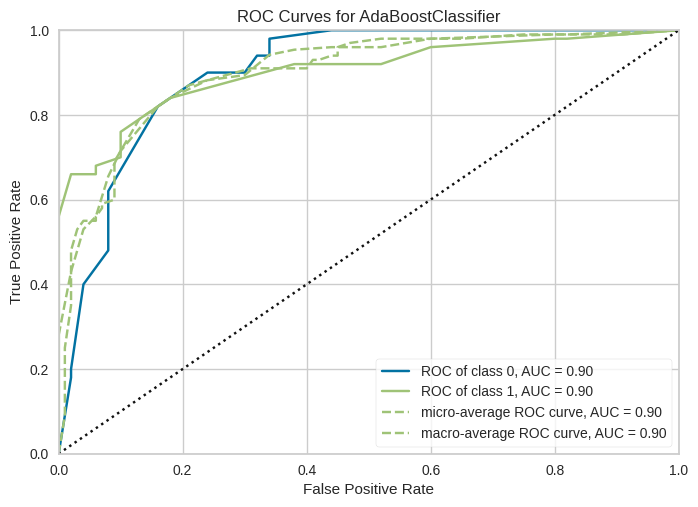

In [17]:
plot_model(best2, plot = 'auc')

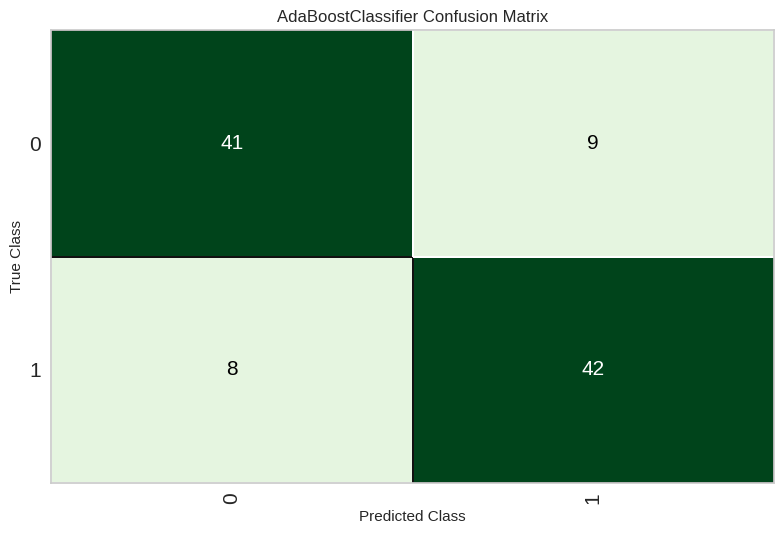

In [18]:
plot_model(best2, plot = 'confusion_matrix')

### **Predictions:**

In [19]:
predict_model(best2)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Ada Boost Classifier,0.8300,0.9020,0.8300,0.8301,0.8300,0.6600,0.6601


,body_mass_g,species,sex,prediction_label,prediction_score
205,3525.0,Chinstrap,Female,Female,0.5048
213,3775.0,Chinstrap,Female,Male,0.5070
110,2900.0,Adelie,Female,Female,0.6786
236,4400.0,Gentoo,Female,Female,0.5268
93,4100.0,Adelie,Male,Male,0.5199
...,...,...,...,...,...
33,3300.0,Adelie,Female,Female,0.5063
196,3325.0,Chinstrap,Female,Female,0.5190
3,3450.0,Adelie,Female,Female,0.5102
243,5250.0,Gentoo,Male,Male,0.6768


### **Save the model:**

In [20]:
save_model(best2, 'penguins_sex_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None, include=['body_mass_g'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_value=None,
                                                               keep_empty_features=False,
                                                               missing_values=nan,
                                                               strategy...
                  TransformerWrapper(exclude=None, include=['species'],
                                     transformer=OneHotEncoder(cols=['species'],
                

# **EXPERIMENT 3:**

3. Third experiment:
    * X = island, bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g
    * y = Sex and Species (multi-label classification)

* PyCaret does not support multi-label classification (predicting both sex and species simultaneously as two targets at the same time), so I built two separate classification models one for species and one for sex using the same features.


### **Setup:**

In [21]:
penguins_exp3 = penguins_clean[['island','bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g','sex','species']]

## MODEL A — Predict Species:

In [22]:
# Model A: Predict species
exp3_species = setup(data=penguins_exp3, target='species', session_id=123)

,Description,Value
0,Session id,123
1,Target,species
2,Target type,Multiclass
3,Target mapping,"Adelie: 0, Chinstrap: 1, Gentoo: 2"
4,Original data shape,"(333, 7)"
5,Transformed data shape,"(333, 9)"
6,Transformed train set shape,"(233, 9)"
7,Transformed test set shape,"(100, 9)"
8,Numeric features,4
9,Categorical features,2


### **Compare Models:**

In [23]:
best3_species = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.2090
lda,Linear Discriminant Analysis,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.1130
et,Extra Trees Classifier,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.2050
lightgbm,Light Gradient Boosting Machine,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.2460
ridge,Ridge Classifier,0.9957,0.0000,0.9957,0.9960,0.9955,0.9931,0.9934,0.0640
lr,Logistic Regression,0.9913,0.0000,0.9913,0.9924,0.9912,0.9865,0.9870,0.2690
gbc,Gradient Boosting Classifier,0.9871,0.0000,0.9871,0.9893,0.9874,0.9803,0.9811,0.3810
xgboost,Extreme Gradient Boosting,0.9871,0.9983,0.9871,0.9890,0.9872,0.9801,0.9809,0.0970
dt,Decision Tree Classifier,0.9786,0.9843,0.9786,0.9822,0.9782,0.9665,0.9685,0.1070
ada,Ada Boost Classifier,0.9571,0.0000,0.9571,0.9669,0.9577,0.9345,0.9389,0.1480


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

In [24]:
best3_species

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='sqrt',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       monotonic_cst=None, n_estimators=100, n_jobs=-1,
                       oob_score=False, random_state=123, verbose=0,
                       warm_start=False)

### **Analyze Model:**

In [25]:
evaluate_model(best3_species)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

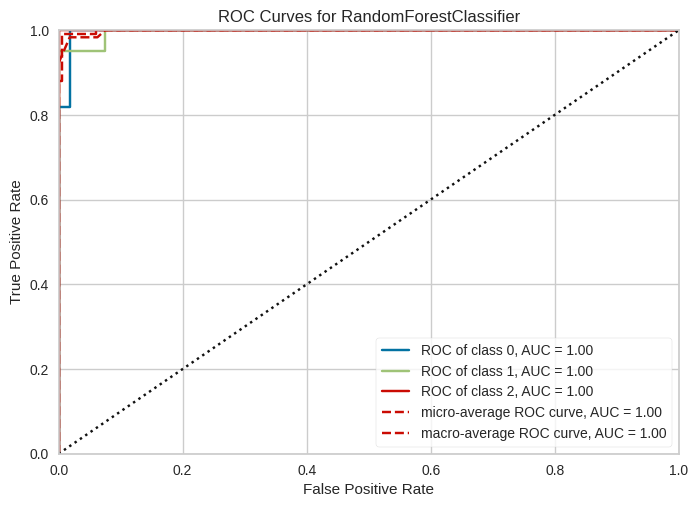

In [26]:
plot_model(best3_species, plot = 'auc')

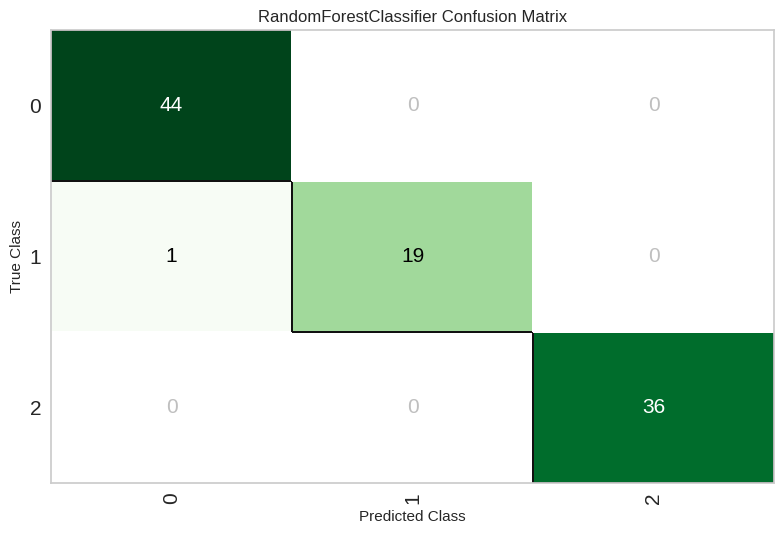

In [27]:
plot_model(best3_species, plot = 'confusion_matrix')

### **Predictions:**

In [28]:
predict_model(best3_species)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.9900,0.9978,0.9900,0.9902,0.9899,0.9842,0.9844


,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,species,prediction_label,prediction_score
84,Dream,35.700001,18.000000,202.0,3550.0,Female,Adelie,Adelie,0.85
109,Biscoe,42.700001,18.299999,196.0,4075.0,Male,Adelie,Adelie,0.82
111,Torgersen,37.299999,20.500000,199.0,3775.0,Male,Adelie,Adelie,1.00
143,Dream,37.799999,18.100000,193.0,3750.0,Male,Adelie,Adelie,0.88
263,Biscoe,46.599998,14.200000,210.0,4850.0,Female,Gentoo,Gentoo,1.00
...,...,...,...,...,...,...,...,...,...
159,Dream,52.000000,18.100000,201.0,4050.0,Male,Chinstrap,Chinstrap,0.96
153,Dream,51.299999,18.200001,197.0,3750.0,Male,Chinstrap,Chinstrap,0.98
140,Dream,39.200001,18.600000,190.0,4250.0,Male,Adelie,Adelie,1.00
310,Biscoe,48.400002,14.400000,203.0,4625.0,Female,Gentoo,Gentoo,0.66


### **Save the model:**

In [29]:
save_model(best3_species, 'penguins_exp3_species_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['bill_length_mm', 'bill_depth_mm',
                                              'flipper_length_mm',
                                              'body_mass_g'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_value=None,...
                  RandomForestClassifier(bootstrap=True, ccp_alpha=0.0,
                                         class_weight=None, criterion='gini',
                                         max_depth=None, max_features='sqrt',
 

## MODEL B — Predict Sex:

### **Setup:**

In [30]:
# Model B: Predict sex
exp3_sex = setup(data=penguins_exp3, target='sex', session_id=123)

,Description,Value
0,Session id,123
1,Target,sex
2,Target type,Binary
3,Target mapping,"Female: 0, Male: 1"
4,Original data shape,"(333, 7)"
5,Transformed data shape,"(333, 11)"
6,Transformed train set shape,"(233, 11)"
7,Transformed test set shape,"(100, 11)"
8,Numeric features,4
9,Categorical features,2


### **Compare Models:**

In [31]:
best3_sex = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lda,Linear Discriminant Analysis,0.9101,0.9717,0.9101,0.9148,0.9098,0.8198,0.8246,0.0630
et,Extra Trees Classifier,0.9060,0.9813,0.9060,0.9152,0.9052,0.8115,0.8207,0.1820
ridge,Ridge Classifier,0.9058,0.9702,0.9058,0.9102,0.9055,0.8112,0.8156,0.0620
rf,Random Forest Classifier,0.9011,0.9733,0.9011,0.9064,0.9006,0.8013,0.8069,0.2130
lr,Logistic Regression,0.8976,0.9522,0.8976,0.9028,0.8971,0.7946,0.8000,0.2440
xgboost,Extreme Gradient Boosting,0.8973,0.9563,0.8973,0.9050,0.8965,0.7938,0.8017,0.0880
gbc,Gradient Boosting Classifier,0.8842,0.9634,0.8842,0.8941,0.8833,0.7674,0.7776,0.2580
lightgbm,Light Gradient Boosting Machine,0.8757,0.9641,0.8757,0.8827,0.8750,0.7506,0.7578,0.2200
ada,Ada Boost Classifier,0.8754,0.9473,0.8754,0.8851,0.8742,0.7497,0.7596,0.1630
dt,Decision Tree Classifier,0.8585,0.8572,0.8585,0.8702,0.8570,0.7156,0.7277,0.0640


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

In [32]:
best3_sex

LinearDiscriminantAnalysis(covariance_estimator=None, n_components=None,
                           priors=None, shrinkage=None, solver='svd',
                           store_covariance=False, tol=0.0001)

### **Analyze Model:**

In [33]:
evaluate_model(best3_sex)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

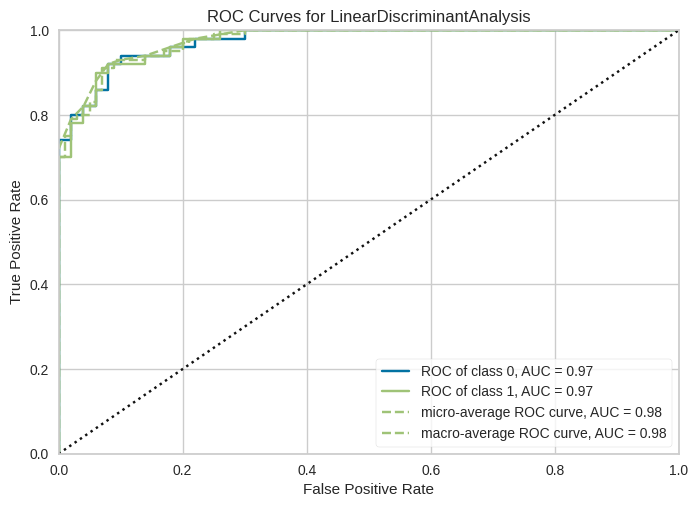

In [34]:
plot_model(best3_sex, plot = 'auc')

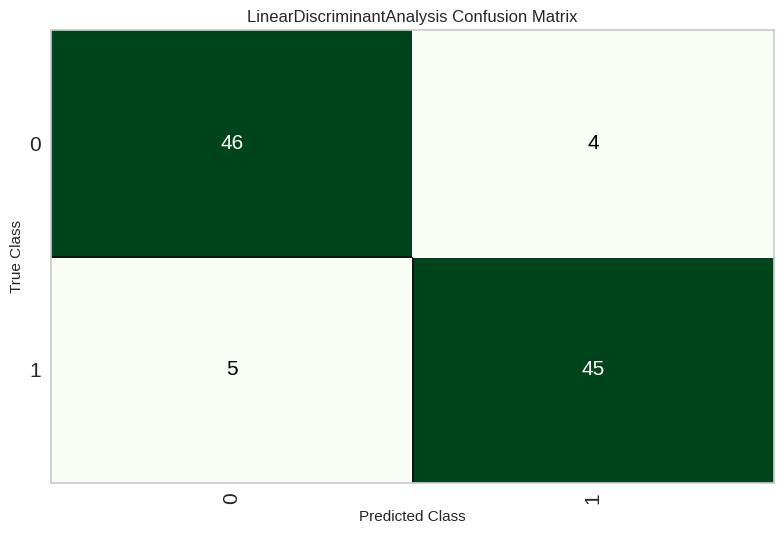

In [35]:
plot_model(best3_sex, plot = 'confusion_matrix')

### **Predictions:**

In [36]:
predict_model(best3_sex)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Linear Discriminant Analysis,0.9100,0.9748,0.9100,0.9102,0.9100,0.8200,0.8202


,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,species,sex,prediction_label,prediction_score
205,Dream,45.599998,19.400000,194.0,3525.0,Chinstrap,Female,Female,0.5773
213,Dream,50.200001,18.700001,198.0,3775.0,Chinstrap,Female,Male,0.8513
110,Torgersen,38.599998,17.000000,188.0,2900.0,Adelie,Female,Female,0.9990
236,Biscoe,46.500000,14.500000,213.0,4400.0,Gentoo,Female,Female,0.9915
93,Dream,43.200001,18.500000,192.0,4100.0,Adelie,Male,Male,0.9867
...,...,...,...,...,...,...,...,...,...
33,Dream,37.599998,19.299999,181.0,3300.0,Adelie,Female,Female,0.7542
196,Dream,48.099998,16.400000,199.0,3325.0,Chinstrap,Female,Female,0.9910
3,Torgersen,36.700001,19.299999,193.0,3450.0,Adelie,Female,Female,0.7579
243,Biscoe,47.299999,15.300000,222.0,5250.0,Gentoo,Male,Male,0.8201


### **Save the model:**

In [37]:
save_model(best3_sex, 'penguins_exp3_sex_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['bill_length_mm', 'bill_depth_mm',
                                              'flipper_length_mm',
                                              'body_mass_g'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_value=None,...
                                     transformer=OneHotEncoder(cols=['island',
                                                                     'species'],
                                                               drop_i